# 1. Header with contributions.

Analysis of Data Across all NBA Games, 1947 - Present
\
Spring 2026 Data Science Project
\
Vincent DePasquale

Contributions:
\
\
Vincent DePasquale -
\
\
A: Project idea - I chose this idea because I am very passionate about the NBA and wanted to investigate and determine a solution to a problem that bothers me as a fan of the NBA.
\
\
B: Dataset Curation and Preprocessing - I found and chose the NBA datasets that contained data on NBA games and team statstics in the NBA games.
\
\
C: Data Exploration and Summary Statistics - I used this data to investigate the effect of elevation on game outcome, the evolution of the three point line, the impact of being the home team in overtime games, and the number of games played in the regular season's effect on predicting a team having a postseason appearance.
\
\
D: ML Algorithm Design/Development - I designed the machine learning approach for the project by choosing classification as the technique to train the model on. Since the goal was to whether a team made the playoffs or not, I selected logisitc regression to use to train the model.
\
\
E: ML Algorithm Training and Test Data Analysis - I trained and tested the model using statistics from the first half of the season as well as statistics from different proportions of regular season games played. The data was split into training and testing sets, and the model was evaluated using accuracy, presision, recall, F1-score, and a confusion matrix.
\
\
F: Visualization, Result Analysis, Conclusion - I created a visualization to show the outcomes of the investigation. The graph I chose and created shows how the number of games played in the regular season can effect the accuracy of the machine learning model at predicting which teams make the playoffs.
\
\
G: Final Tutorial Report Creation - I wrote and organized the final tutorial report, including the project explanation, data preprocessing steps, machine learning techniques, visualizations, analysis, and conclusions.



---

# 2. Introduction

Our topic is NBA games. We are investigating if we can take data from every NBA game from 1947-Present and filter it down to answer questions and learn more about the game of basketball. Specifically, can data from games in certain parts of the season be used to predict outcomes later in the season. Can we use data from the first half of the season to predict if teams will make the playoffs at the end of the regular season? This is important to know because a main concern that has arisen in the NBA in recent years is the massive injury problem. In recent years injuries have increased in terms of both significance and frequency. A large reason for this is the strain on the players bodies due to the large amount of games they play. The thinking behind our data analysis is that if our machine learning model can accurately and precisely predict which NBA teams will go on to make the playoffs based just on data in the first half of the season, then the second half of the season is essentially irrelavent. This would mean the NBA could shorten the amount of games played in a regular season, thus decreasing the amount of injuries and making basketball an overall more enjoyable experience for both the players and the viewer. We will then be looking at how different models perform using the same data but being trained on a different portion of games for that season. We are attemping to determine how accuracy increases as the number of games played in the regular season the model is trained on increases. For example, how does the model do at predicting what teams make the playoffs after 20 regular season games played versus 80 regular season games played. Is there a number of games played where the accuray of the model plateaus? This could potentially be a good cut off point where the NBA season could be shortened to to prevent as much strain on the athletes and decrease injuries.

---

#3. Data curation

In [17]:
import kagglehub
import os
import pandas as pd
import requests
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import statsmodels.api as sm
import zipfile
import warnings
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# NBA games data is from https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores
nba_games_url = "https://raw.githubusercontent.com/vdepasqu/vdepasquCMSC320FinalProject/main/Games.csv"
nba_teams_stats_url = "https://raw.githubusercontent.com/vdepasqu/vdepasquCMSC320FinalProject/main/TeamStatistics.csv"
nba_teams_stats_misc_url = "https://raw.githubusercontent.com/vdepasqu/vdepasquCMSC320FinalProject/main/TeamStatisticsMisc.csv"

games_df = pd.read_csv(nba_games_url)
team_stats_df = pd.read_csv(nba_teams_stats_url)
team_stats_misc_df = pd.read_csv(nba_teams_stats_misc_url)

# worldcities.csv is from https://simplemaps.com/data/world-cities
world_cities_url = "https://raw.githubusercontent.com/vdepasqu/vdepasquCMSC320FinalProject/main/worldcities.csv"
cities_df = pd.read_csv(world_cities_url)

warnings.filterwarnings('ignore')

The data listed here that we will be investigating is data on all NBA games from 1947-Present. We specifically selected data on the games, team statistics, and other miscellaneous team statistics. We also explored data on the different cities that the NBA teams were located in for later investigation.
\
\
First, we have to filter out the games data to grab just the columns that we need. This includes the gameId, the data of the game, the home team and its city, the away team and its city, home score, and away score. The NBA has gone through various transitions in its over 75 year history including a merger with another basketball league. There were very little teams back then and basketball was such a different sport so we removed all the games before the ABA-NBA merger. Next, we had to take into account that some cities have multiple NBA teams and that over the course of the NBA teams have switched cities so we had to clean up the data to take this into account.

In [18]:
games_df = games_df[['gameId', 'gameDateTimeEst', 'hometeamCity', 'hometeamName', 'awayteamCity', 'awayteamName', 'homeScore', 'awayScore']]

# Remove games before the ABA NBA merger
games_df["gameDateTimeEst"] = pd.to_datetime(games_df["gameDateTimeEst"])
games_df = games_df[games_df["gameDateTimeEst"] > "1976-06-10 00:00:00"]

team_to_city = {
    'Denver': 'Denver',
    'Oklahoma City': 'Oklahoma City',
    'New Orleans': 'New Orleans',
    'Brooklyn': 'Brooklyn',
    'Portland': 'Portland',
    'Toronto': 'Toronto',
    'Charlotte': 'Charlotte',
    'Indiana': 'Indianapolis',
    'Milwaukee': 'Milwaukee',
    'Phoenix': 'Phoenix',
    'Memphis': 'Memphis',
    'Atlanta': 'Atlanta',
    'Minnesota': 'Minneapolis',
    'Los Angeles': 'Los Angeles',
    'Golden State': 'San Francisco',
    'Boston': 'Boston',
    'Cleveland': 'Cleveland',
    'Detroit': 'Detroit',
    'Orlando': 'Orlando',
    'LA': 'Los Angeles',
    'Utah': 'Salt Lake City',
    'Philadelphia': 'Philadelphia',
    'New York': 'New York',
    'Dallas': 'Dallas',
    'Chicago': 'Chicago',
    'Miami': 'Miami',
    'Sacramento': 'Sacramento',
    'San Antonio': 'San Antonio',
    'Houston': 'Houston',
    'Washington': 'Washington',
    'New Jersey': 'Brooklyn',
    'Seattle': 'Seattle',
    'Vancouver': 'Vancouver',
    'Kansas City': 'Kansas City',
    'San Diego': 'San Diego',
    'Buffalo': 'Buffalo'
}
games_df['homeMappedCity'] = games_df['hometeamCity'].map(team_to_city)
games_df['awayMappedCity'] = games_df['awayteamCity'].map(team_to_city)

display(games_df)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,awayteamCity,awayteamName,homeScore,awayScore,homeMappedCity,awayMappedCity
0,42500172,2026-04-21 22:30:00,Los Angeles,Lakers,Houston,Rockets,101,94,Los Angeles,Houston
1,42500152,2026-04-21 20:00:00,San Antonio,Spurs,Portland,Trail Blazers,103,106,San Antonio,Portland
2,42500112,2026-04-21 19:00:00,Boston,Celtics,Philadelphia,76ers,97,111,Boston,Philadelphia
3,42500162,2026-04-20 22:30:00,Denver,Nuggets,Minnesota,Timberwolves,114,119,Denver,Minneapolis
4,42500122,2026-04-20 20:00:00,New York,Knicks,Atlanta,Hawks,106,107,New York,Atlanta
...,...,...,...,...,...,...,...,...,...,...
61116,27600009,1976-10-22 19:00:00,Indiana,Pacers,Denver,Nuggets,110,123,Indianapolis,Denver
61117,27600006,1976-10-21 19:00:00,Atlanta,Hawks,Houston,Rockets,104,120,Atlanta,Houston
61118,27600005,1976-10-21 19:00:00,Milwaukee,Bucks,Buffalo,Braves,112,133,Milwaukee,Buffalo
61119,27600007,1976-10-21 19:00:00,New York,Knicks,Los Angeles,Lakers,102,97,New York,Los Angeles


---

#4. Exploratory data analysis.

I will be seeing if elevation differential between the home and away team has an impact point differential. The idea is at higher elevations, the atmosphere is thinner and there is less oxygen which allows the home team to adapt to that environment. Because of this we might expect a lower elevation team to struggle slightly more at higher elevations and a higher elevation team to succeed more at lower elevations. <br><br> **Null Hypothesis:** Elevation differential between the home and away team has no effect on point difference of the game <br><br> **Alternative Hypothesis:** Elevation differential has a difference on point differential benefiting the team with the higher elevation home city

In [19]:
# Limit dataset size by filtering just cities in usa/canada with pop > 100000 and matches with games dataframe
filtered_cities_df = cities_df[(cities_df['country'] == "United States") | (cities_df['country'] == "Canada")]
filtered_cities_df = filtered_cities_df[filtered_cities_df['city'].isin(games_df['homeMappedCity'].dropna())]
filtered_cities_df = filtered_cities_df[filtered_cities_df['population'] > 100000]
# Take out duplicate city names for incorrect city
filtered_cities_df = filtered_cities_df[filtered_cities_df['id'] != 1840000327] # Portland, Maine
filtered_cities_df = filtered_cities_df[filtered_cities_df['id'] != 1840001626] # Kansas City, Kansas
filtered_cities_df = filtered_cities_df[filtered_cities_df['id'] != 1840021189] # Vancouver, Washington
# filter dataframe to just what i need and reset index
filtered_cities_df = filtered_cities_df[['city', 'lat', 'lng', 'population']]
filtered_cities_df = filtered_cities_df.reset_index(drop=True)

# json get request for elevation based on lat/long
def get_elevation(lat, lng):
    url = "https://epqs.nationalmap.gov/v1/json"
    params = {
        "x": lng,
        "y": lat,
        "units": "Feet"
    }

    response = requests.get(url, params=params)
    data = response.json()
    return data["value"]

# apply elevation func to add elevation column
filtered_cities_df["elevation"] = filtered_cities_df.apply(
    lambda row: get_elevation(row["lat"], row["lng"]),
    axis=1
)

# round to nearest foot
filtered_cities_df["elevation"] = filtered_cities_df["elevation"].round(1)

display(filtered_cities_df)

,city,lat,lng,population,elevation
0,New York,40.6943,-73.9249,18832416.0,55.8
1,Los Angeles,34.1141,-118.4068,11885717.0,1108.3
2,Chicago,41.8375,-87.6866,8489066.0,576.1
3,Miami,25.7840,-80.2101,6113982.0,0.2
4,Houston,29.7860,-95.3885,6046392.0,51.8
5,Dallas,32.7935,-96.7667,5843632.0,482.3
6,Philadelphia,40.0077,-75.1339,5696588.0,103.2
7,Toronto,43.7417,-79.3733,5647656.0,490.9
8,Atlanta,33.7628,-84.4220,5211164.0,959.1
9,Washington,38.9047,-77.0163,5146120.0,63.7


In [20]:
# Add columns for home team elevation, away team elevation, home team point differenetial, home team elevation differential
games_df['hometeamElevation'] = games_df['homeMappedCity'].map(filtered_cities_df.set_index('city')['elevation'])
games_df['awayteamElevation'] = games_df['awayMappedCity'].map(filtered_cities_df.set_index('city')['elevation'])
games_df['hometeamPointDiff'] = games_df['homeScore'] - games_df['awayScore']
games_df['hometeamElevDiff'] = games_df['hometeamElevation'] - games_df['awayteamElevation']
display(games_df)

,gameId,gameDateTimeEst,hometeamCity,hometeamName,awayteamCity,awayteamName,homeScore,awayScore,homeMappedCity,awayMappedCity,hometeamElevation,awayteamElevation,hometeamPointDiff,hometeamElevDiff
0,42500172,2026-04-21 22:30:00,Los Angeles,Lakers,Houston,Rockets,101,94,Los Angeles,Houston,1108.3,51.8,7,1056.5
1,42500152,2026-04-21 20:00:00,San Antonio,Spurs,Portland,Trail Blazers,103,106,San Antonio,Portland,723.3,161.9,-3,561.4
2,42500112,2026-04-21 19:00:00,Boston,Celtics,Philadelphia,76ers,97,111,Boston,Philadelphia,71.9,103.2,-14,-31.3
3,42500162,2026-04-20 22:30:00,Denver,Nuggets,Minnesota,Timberwolves,114,119,Denver,Minneapolis,5286.9,862.8,-5,4424.1
4,42500122,2026-04-20 20:00:00,New York,Knicks,Atlanta,Hawks,106,107,New York,Atlanta,55.8,959.1,-1,-903.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61116,27600009,1976-10-22 19:00:00,Indiana,Pacers,Denver,Nuggets,110,123,Indianapolis,Denver,717.7,5286.9,-13,-4569.2
61117,27600006,1976-10-21 19:00:00,Atlanta,Hawks,Houston,Rockets,104,120,Atlanta,Houston,959.1,51.8,-16,907.3
61118,27600005,1976-10-21 19:00:00,Milwaukee,Bucks,Buffalo,Braves,112,133,Milwaukee,Buffalo,711.5,638.9,-21,72.6
61119,27600007,1976-10-21 19:00:00,New York,Knicks,Los Angeles,Lakers,102,97,New York,Los Angeles,55.8,1108.3,5,-1052.5


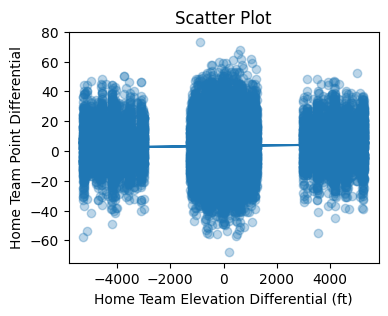

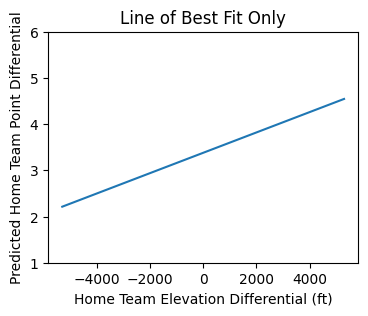

Slope: 0.00022045761425869715
Intercept: 3.3790094602419196
Pearson r: 0.027210058977988442
p-value: 1.7267009259500078e-11


In [21]:
plot_df = games_df[['hometeamElevDiff', 'hometeamPointDiff']].copy()
plot_df = plot_df.dropna()

x = plot_df['hometeamElevDiff']
y = plot_df['hometeamPointDiff']

# Scatter Plot
plt.figure(figsize=(4, 3))
plt.scatter(x, y, alpha=0.3)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b)

plt.xlabel('Home Team Elevation Differential (ft)')
plt.ylabel('Home Team Point Differential')
plt.title('Scatter Plot')
plt.show()

# Line of Best Fit
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 500)
y_line = m * x_line + b

plt.figure(figsize=(4, 3))
plt.plot(x_line, y_line)

plt.xlabel('Home Team Elevation Differential (ft)')
plt.ylabel('Predicted Home Team Point Differential')
plt.title('Line of Best Fit Only')
plt.ylim(1, 6)

plt.show()

# Data
r, p = pearsonr(plot_df['hometeamElevDiff'], plot_df['hometeamPointDiff'])

print("Slope:", m)
print("Intercept:", b)
print("Pearson r:", r)
print("p-value:", p)

Although the scatter plot is difficult to decipher by itself, the slope of the line of best fit shows that for every increase in one foot of elevation for the differential between a home teams elevation and the away teams elevation, you would expect an increase of 0.0002 points for the point differential between the home team and the away team. This does not seem like much but for every 1,000 feet of elevation this is 0.219 points. The highest elevation team in the NBA is the Denver Nuggets at 5286.9 feet above sea level and the lowest is the New Orleans Pelicans at 2.9 below sea level. This means there different in elevation is 5289.9 feet which equates to an expected point differential of 1.156 points when these two teams play eachother. With 61,490 games as data points this equates to a p value of 2.38518e-11 which is statisically signifcant thus we reject the null hypothesis.



---



We will be investigating the evolution of the three point shot over time in the NBA. We believe that since the three point line was established in the 1979-80 season, teams have taken a higher volume of three point shots year over year. We believe at the begining there was a rapid increase in three point percentage but that it eventually flattened but that the volume continued to increase steadily. <br><br>**Null Hypothesis:** There is no relationship between three point attempts and three point percentage over time. <br><br>**Alternative Hypothesis:** There is a relationship between three point attempts and three point percentage over time.

In [22]:
# set up dataframes
team_scoring_df = team_stats_df
games_df = pd.read_csv(nba_games_url)

team_scoring_df = team_scoring_df[['gameId','gameDateTimeEst','teamCity','teamName','opponentTeamName','opponentTeamCity','home','win','threePointersAttempted','threePointersMade','threePointersPercentage']]
games_df = games_df[['gameId', 'gameType']]

# Remove games before the adaption of the three point line
team_scoring_df["gameDateTimeEst"] = pd.to_datetime(team_scoring_df["gameDateTimeEst"])
team_scoring_df = team_scoring_df[team_scoring_df["gameDateTimeEst"] > "1979-10-11 00:00:00"]
team_scoring_df = team_scoring_df.dropna(subset=['threePointersAttempted','threePointersMade','threePointersPercentage'])

# Just regular season games
regular_season_ids_df = games_df[games_df['gameType'] == "Regular Season"]
team_scoring_df = team_scoring_df[team_scoring_df['gameId'].isin(regular_season_ids_df['gameId'])]

# Break down dates and divide the games into their individual seasons
def season_divide(date):
  if date.month >= 9:
    start_year = date.year
    end_year = date.year + 1
  else:
    start_year = date.year - 1
    end_year = date.year
  return f"{start_year}-{str(end_year)[-2:]}"

team_scoring_df['gameDateTimeEst'] = pd.to_datetime(team_scoring_df['gameDateTimeEst'])
team_scoring_df['season'] = team_scoring_df['gameDateTimeEst'].apply(season_divide)

display(team_scoring_df)

,gameId,gameDateTimeEst,teamCity,teamName,opponentTeamName,opponentTeamCity,home,win,threePointersAttempted,threePointersMade,threePointersPercentage,season
40,22501195,2026-04-12 20:30:00,New Orleans,Pelicans,Timberwolves,Minnesota,0,0.0,21.0,5.0,0.238,2025-26
41,22501193,2026-04-12 20:30:00,Chicago,Bulls,Mavericks,Dallas,0,0.0,38.0,10.0,0.263,2025-26
42,22501193,2026-04-12 20:30:00,Dallas,Mavericks,Bulls,Chicago,1,1.0,49.0,22.0,0.449,2025-26
43,22501197,2026-04-12 20:30:00,Denver,Nuggets,Spurs,San Antonio,0,1.0,30.0,11.0,0.367,2025-26
44,22501199,2026-04-12 20:30:00,Golden State,Warriors,Clippers,LA,0,0.0,39.0,11.0,0.282,2025-26
...,...,...,...,...,...,...,...,...,...,...,...,...
112485,28100073,1981-11-11 20:00:00,Philadelphia,76ers,Bulls,Chicago,1,1.0,1.0,0.0,0.000,1981-82
112501,28100068,1981-11-10 20:00:00,Philadelphia,76ers,Pistons,Detroit,0,1.0,1.0,0.0,0.000,1981-82
112509,28100068,1981-11-10 20:00:00,Detroit,Pistons,76ers,Philadelphia,1,0.0,1.0,0.0,0.000,1981-82
112581,28100023,1981-11-03 20:00:00,Philadelphia,76ers,Bullets,Washington,0,1.0,1.0,0.0,0.000,1981-82


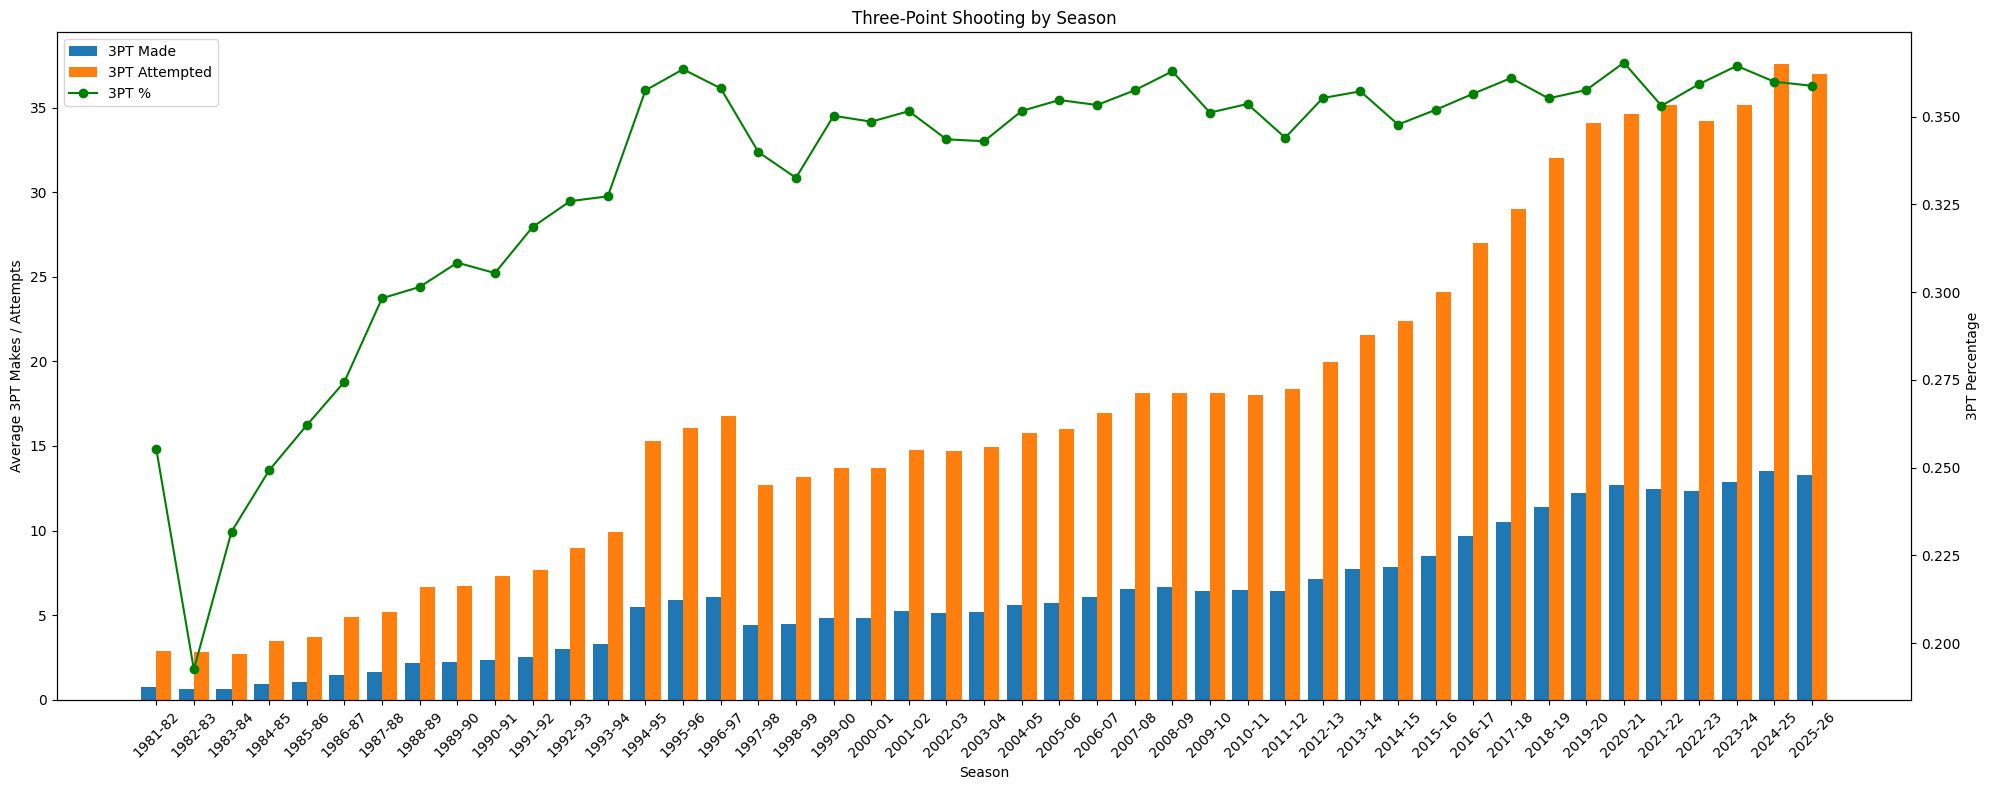

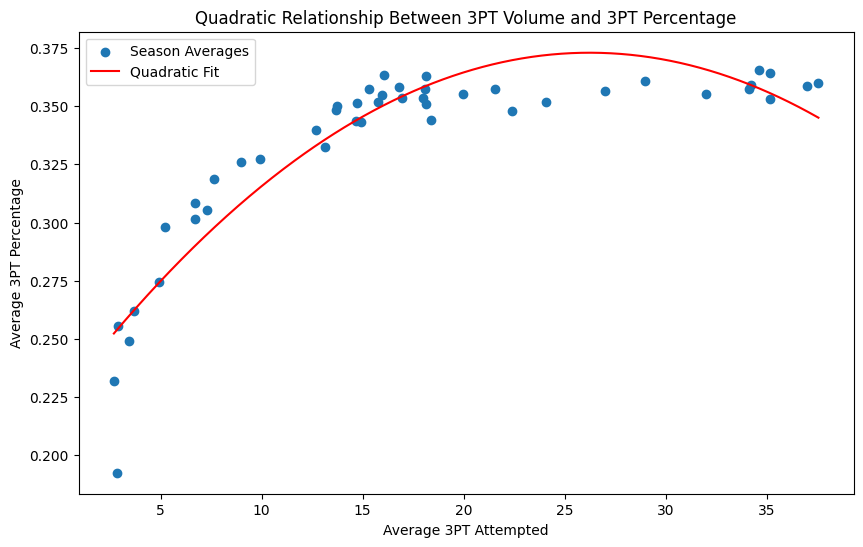

R-squared: 0.8686997796302657
F-test p-value: 3.0449106618779794e-19


In [23]:
# bar graph
plot_df = team_scoring_df.groupby('season')[['threePointersAttempted', 'threePointersMade', 'threePointersPercentage']].mean().reset_index()
plot_df = plot_df.sort_values('season')

x = np.arange(len(plot_df))
width = 0.4

fig, xaxis = plt.subplots(figsize=(20, 8))

xaxis.bar(x - width/2, plot_df['threePointersMade'], width, label='3PT Made')
xaxis.bar(x + width/2, plot_df['threePointersAttempted'], width, label='3PT Attempted')
xaxis.set_xlabel('Season')
xaxis.set_ylabel('Average 3PT Makes / Attempts')
xaxis.set_xticks(x)
xaxis.set_xticklabels(plot_df['season'], rotation=45)

yaxis = xaxis.twinx()
yaxis.plot(x, plot_df['threePointersPercentage'], marker='o', label='3PT %', color='green')
yaxis.set_ylabel('3PT Percentage')

lines1, labels1 = xaxis.get_legend_handles_labels()
lines2, labels2 = yaxis.get_legend_handles_labels()
xaxis.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Three-Point Shooting by Season')
plt.tight_layout()
plt.show()

# quadratic relationship between 3 point volume and 3 point percentage graph
x = plot_df['threePointersAttempted']
y = plot_df['threePointersPercentage']

a, b, c = np.polyfit(x, y, 2)

x_curve = np.linspace(x.min(), x.max(), 500)
y_curve = a * x_curve**2 + b * x_curve + c

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Season Averages')
plt.plot(x_curve, y_curve, label='Quadratic Fit', color='red')
plt.xlabel('Average 3PT Attempted')
plt.ylabel('Average 3PT Percentage')
plt.title('Quadratic Relationship Between 3PT Volume and 3PT Percentage')
plt.legend()
plt.show()

x = plot_df['threePointersAttempted']
y = plot_df['threePointersPercentage']

X = np.column_stack((x, x**2))
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print("R-squared:", model.rsquared)
print("F-test p-value:", model.f_pvalue)

It appears that over time since the addition of the three point shot in the NBA, each year both the average number of three point shot per team per game and the average number of three point makes per team per game has increased. However, the three point percentage did rapidly increase until it flattened out in the mid 1990s and has hasn't drastically increased nor decreased since. <br><br>A quadratic regression model supports this observation. The model produced an $R^2$ value of 0.869 which means that 86.9% of the variation in average three point percentage can be explained by average three point volume when a curved relationship is allowed.<br><br>This model was also statistically significant with a p-value of 3.009e-19, which means the the curved relationship between three point percentage and three point volume is highly unlikely to be due to chance alone.

---

We will be investigating whether there is a statistically significant difference in chance of winning a home game in the NBA depending on if the game goes to overtime or ends in regulation. The idea behind this is to test home court advantage and see if home court advantage has a bigger role in closer more tense games. <br><br>
**Null Hypothesis:** There is no relationship between the outcome of a game depending on if the game ends in regulation or in overtime.
<br><br>
**Alternative Hypothesis:** There is a relationship between the outcome of a game depending on if the game ends in regulation or in overtime.

In [24]:
team_misc_df = team_stats_misc_df

team_misc_df = team_misc_df[['gameId', 'teamName', 'gameType', 'gameDateTimeEst', 'home', 'min', 'win']]

# Remove games before the ABA NBA merger
team_misc_df["gameDateTimeEst"] = pd.to_datetime(team_misc_df["gameDateTimeEst"])
team_misc_df = team_misc_df[team_misc_df["gameDateTimeEst"] > "1976-06-10 00:00:00"]

# Filter to only regular season and home games
team_misc_df = team_misc_df[team_misc_df['gameType'] == "Regular Season"]
team_misc_df = team_misc_df[team_misc_df['home'] == 1.0]

# reset index
team_misc_df = team_misc_df.reset_index(drop=True)

# add overtime collumn based on if game went over 48 minuts (regulation game length)
team_misc_df['overtime'] = (team_misc_df['min'] > 48).astype(int)

# group by wins and overtime then filter out rows with losses to just get rows of wins or overtime and no overtime
overtime_win_grouped = team_misc_df.groupby(['overtime', 'win']).size().reset_index(name='count')
wins_df = overtime_win_grouped[overtime_win_grouped['win'] != 0]
wins_df = wins_df.reset_index(drop=True)

# add column for win percentage so there is a table with total overtime and
# non overtime games and corresponding win percentage outcome
overtime_grouped = team_misc_df.groupby('overtime').size().reset_index(name='count')
overtime_grouped['win_percentage'] = wins_df['count'] / overtime_grouped['count']
display(overtime_grouped)


,overtime,count,win_percentage
0,0,733,0.548431
1,1,39,0.615385


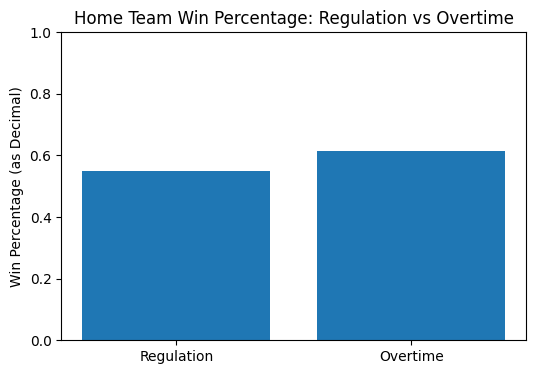

Chi-squared: 0.4277694144492823
Chi-squared p-value: 0.5130854972186888
t-test: -0.8262142023459406
t-test p-value: 0.4133258770398983


In [25]:
# bar graph
plot_df = overtime_grouped.copy()
plot_df['game_type'] = plot_df['overtime'].map({0: 'Regulation', 1: 'Overtime'})

plt.figure(figsize=(6,4))
plt.bar(plot_df['game_type'], plot_df['win_percentage'])
plt.ylabel('Win Percentage (as Decimal)')
plt.title('Home Team Win Percentage: Regulation vs Overtime')
plt.ylim(0, 1)
plt.show()

# chi squared test
contingency_table = pd.crosstab(team_misc_df['overtime'], team_misc_df['win'])
contingency_table

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared:", chi2)
print("Chi-squared p-value:", p)

# t test
regulation_wins = team_misc_df[team_misc_df['overtime'] == 0]['win']
overtime_wins = team_misc_df[team_misc_df['overtime'] == 1]['win']

t_stat, p_val = ttest_ind(regulation_wins, overtime_wins, equal_var=False)

print("t-test:", t_stat)
print("t-test p-value:", p_val)



The data showed that home teams won at a slightly higher rate in overtime games than in regulation games, but the statistical tests indicated that this difference was not significant. The chi-squared test produced a test statistic of 0.428 with a p-value of 0.513, and the t-test produced a test statistic of -0.826 with a p-value of 0.413. Because both p-values are greater than 0.05, the null hypothesis fails to be rejected. This means there is not enough evidence to conclude that home teams have a statistically significant change in their probability of winning when a game goes to overtime rather than ending in regulation.

---

#5. Primary analysis.

The machine learning technique we will be using for our invesitgation is classifcation. We are using classification because our outcome is categorical, whether the team made the playoffs at the end of the season or did not make the playoffs at the end of the season. We will be using logistic regression to train the model because logistic regression is designed for binary classification problems. We will be investigating if how the team is doing during the first half of the season is a good indicator for if they will make the playoffs and how far they will go into the playoffs.

In [26]:
# set up dataframes, chose specific columns that could be used to indicate team sucess
team_stats_df = pd.read_csv(nba_teams_stats_url)
games_df = pd.read_csv(nba_games_url)
team_stats_df = team_stats_df[['gameId','gameDateTimeEst','teamCity','teamName', 'teamScore', 'opponentScore', 'threePointersMade', 'win',
                                   'assists', 'blocks', 'steals', 'reboundsTotal', 'turnovers', 'seasonWins', 'seasonLosses']]
games_df = games_df[['gameId', 'gameDateTimeEst', 'hometeamCity', 'hometeamName', 'gameType', 'gameLabel']]

# Remove games before the adaption of the three point line and ABA-NBA merger as well as when the NBA started keeping track of more data
team_stats_df["gameDateTimeEst"] = pd.to_datetime(team_stats_df["gameDateTimeEst"])
team_stats_df = team_stats_df[team_stats_df["gameDateTimeEst"] > "1985-10-11 00:00:00"]
team_stats_df = team_stats_df.dropna(subset=['threePointersMade'])

games_df["gameDateTimeEst"] = pd.to_datetime(games_df["gameDateTimeEst"])
games_df = games_df[games_df["gameDateTimeEst"] > "1985-10-11 00:00:00"]

# Break down dates and divide the games into their individual seasons
def season_divide(date):
  if date.month >= 9:
    start_year = date.year
    end_year = date.year + 1
  else:
    start_year = date.year - 1
    end_year = date.year
  return f"{start_year}-{str(end_year)[-2:]}"

team_stats_df['season'] = team_stats_df['gameDateTimeEst'].apply(season_divide)
games_df['season'] = games_df['gameDateTimeEst'].apply(season_divide)

# removal of seaons that were shorted due to various reasons such as blackouts or pandemics
shortened_seasons = ['1998-99', '2011-12', '2019-20']
team_stats_df = team_stats_df[~team_stats_df['season'].isin(shortened_seasons)]
games_df = games_df[~games_df['season'].isin(shortened_seasons)]

# creates a dataframe of just playoff games
playoff_game_ids = games_df[games_df['gameType'] == 'Playoffs']['gameId']
# creates a dataframe of just teams that went to the playoffs
playoff_teams_df = team_stats_df[team_stats_df['gameId'].isin(playoff_game_ids)]

# creates a dataframe that groups teams by season and playoffs so it is just a single entry per team per season on playoff appearance
# then adds column with a value of one to indicate that team made the playoffs for that season
playoff_labels_df = (playoff_teams_df.groupby(['season', 'teamCity', 'teamName']).size().reset_index(name='playoffGames'))
playoff_labels_df['madePlayoffs'] = 1

# creates a dataframe of just regular season games
regular_game_ids = games_df[games_df['gameType'] == 'Regular Season']['gameId']
# creates a dataframe of just regular season games but for team_stats_df
regular_team_stats_df = team_stats_df[team_stats_df['gameId'].isin(regular_game_ids)]

# sort each team in order of season, team, and date
regular_team_stats_df = regular_team_stats_df.sort_values(by=['season', 'teamCity', 'teamName', 'gameDateTimeEst'])
# create a counter for which number game of the regular season it is and then remove all games before the halfway point of the season
regular_team_stats_df['gameNumber'] = (regular_team_stats_df.groupby(['season', 'teamCity', 'teamName']).cumcount() + 1)
first_half_df = regular_team_stats_df[regular_team_stats_df['gameNumber'] <= 41]

# calculate and add point differiental as a column
first_half_df['pointDiff'] = first_half_df['teamScore'] - first_half_df['opponentScore']

# calculate the season averages and win total for all the data points we will be using to train the machine learning model
first_half_summary_df = (first_half_df.groupby(['season', 'teamCity', 'teamName']).agg(
    firstHalfGames=('gameId', 'count'),
    firstHalfWins=('win', 'sum'),
    avgTeamScore=('teamScore', 'mean'),
    avgOpponentScore=('opponentScore', 'mean'),
    avgPointDiff=('pointDiff', 'mean'),
    avgThreePointersMade=('threePointersMade', 'mean'),
    avgAssists=('assists', 'mean'),
    avgBlocks=('blocks', 'mean'),
    avgSteals=('steals', 'mean'),
    avgRebounds=('reboundsTotal', 'mean'),
    avgTurnovers=('turnovers', 'mean')
).reset_index())

# calculate win percentage per team per year for the first half of the season
first_half_summary_df['firstHalfWinPct'] = (first_half_summary_df['firstHalfWins'] / first_half_summary_df['firstHalfGames'])

# merge data and create final dataframe which we will use to train the machine learning model
model_df = first_half_summary_df.merge(playoff_labels_df[['season', 'teamCity', 'teamName', 'madePlayoffs']],
                                       on=['season', 'teamCity', 'teamName'],how='left')
model_df['madePlayoffs'] = model_df['madePlayoffs'].fillna(0).astype(int)

display(model_df)


,season,teamCity,teamName,firstHalfGames,firstHalfWins,avgTeamScore,avgOpponentScore,avgPointDiff,avgThreePointersMade,avgAssists,avgBlocks,avgSteals,avgRebounds,avgTurnovers,firstHalfWinPct,madePlayoffs
0,1985-86,Atlanta,Hawks,41,24.0,107.195122,105.658537,1.536585,0.512195,23.170732,5.317073,9.658537,43.560976,18.317073,0.585366,1
1,1985-86,Boston,Celtics,41,33.0,114.121951,106.365854,7.756098,1.341463,29.268293,6.317073,8.926829,45.609756,17.048780,0.804878,1
2,1985-86,Chicago,Bulls,41,15.0,110.780488,114.317073,-3.536585,1.341463,24.170732,5.512195,6.536585,43.951220,17.268293,0.365854,1
3,1985-86,Cleveland,Cavaliers,41,18.0,109.024390,109.902439,-0.878049,1.195122,25.341463,5.390244,7.853659,44.439024,17.780488,0.439024,0
4,1985-86,Dallas,Mavericks,41,20.0,114.731707,115.024390,-0.292683,1.317073,25.439024,4.195122,7.536585,44.268293,17.024390,0.487805,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1083,2025-26,Sacramento,Kings,41,11.0,110.195122,120.707317,-10.512195,10.463415,24.853659,4.414634,8.707317,40.560976,13.634146,0.268293,0
1084,2025-26,San Antonio,Spurs,41,28.0,117.634146,112.487805,5.146341,12.951220,25.585366,4.463415,7.878049,46.756098,13.365854,0.682927,1
1085,2025-26,Toronto,Raptors,41,24.0,113.853659,112.341463,1.512195,11.560976,29.341463,4.512195,8.658537,43.073171,13.170732,0.585366,1
1086,2025-26,Utah,Jazz,41,14.0,119.341463,127.390244,-8.048780,13.463415,30.121951,3.390244,7.756098,44.341463,15.365854,0.341463,0


Now that we have filtered and gathered all the data we want, we have a dataframe that contains a collection of rows for every team and season that consists of several relevant statistics for basketball success along with if the team ended up making the playoffs after the second half of the season was concluded. We then took this dataframe and used it to create our machine learning model that used logistic regression with classification as the technique to predict if the team will make the playoffs based off of their first half of the season success.

In [27]:
# what statistics we are using to train the model
features = [
    'firstHalfGames',
    'firstHalfWins',
    'avgTeamScore',
    'avgOpponentScore',
    'avgPointDiff',
    'avgThreePointersMade',
    'avgAssists',
    'avgBlocks',
    'avgSteals',
    'avgRebounds',
    'avgTurnovers',
    'firstHalfWinPct'
]

# building and training the model
X = model_df[features]
y = model_df['madePlayoffs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
log_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# displaying results
print("Accuracy:", accuracy)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Accuracy: 0.8623853211009175

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        96
           1       0.87      0.89      0.88       122

    accuracy                           0.86       218
   macro avg       0.86      0.86      0.86       218
weighted avg       0.86      0.86      0.86       218


Confusion Matrix:
[[ 79  17]
 [ 13 109]]


---

We will now investigate the accuracy of predicitng postseason appearances after different number of games played. We will train serveral models and gather the accuracies using numbers of games played from 20 games to 80 games incrementing by 5 games played at a time.

In [33]:
# number of regular season games played in the season used to train the model
games_to_test = [20,25,30,35,40,45,50,55,60,65,70,75,80]
accuracy_results = []

# training and running the model for each number of games played and then adding the accuray score to accuracy_results
for num_games in games_to_test:

  temp_df = regular_team_stats_df[regular_team_stats_df['gameNumber'] <= num_games]

  # calculate and add point differiental as a column
  temp_df['pointDiff'] = temp_df['teamScore'] - temp_df['opponentScore']

  # calculate the season averages and win total for all the data points we will be using to train the machine learning model
  temp_summary_df = (temp_df.groupby(['season', 'teamCity', 'teamName']).agg(
    games=('gameId', 'count'),
    wins=('win', 'sum'),
    avgTeamScore=('teamScore', 'mean'),
    avgOpponentScore=('opponentScore', 'mean'),
    avgPointDiff=('pointDiff', 'mean'),
    avgThreePointersMade=('threePointersMade', 'mean'),
    avgAssists=('assists', 'mean'),
    avgBlocks=('blocks', 'mean'),
    avgSteals=('steals', 'mean'),
    avgRebounds=('reboundsTotal', 'mean'),
    avgTurnovers=('turnovers', 'mean')
  ).reset_index())

  # calculate win percentage per team per year for the first half of the season
  temp_summary_df['winPct'] = (temp_summary_df['wins'] / temp_summary_df['games'])

  # merge data and create final dataframe which we will use to train the machine learning model
  temp_model_df = temp_summary_df.merge(playoff_labels_df[['season', 'teamCity', 'teamName', 'madePlayoffs']],
                                       on=['season', 'teamCity', 'teamName'],how='left')

  temp_model_df['madePlayoffs'] = temp_model_df['madePlayoffs'].fillna(0).astype(int)

  # what statistics we are using to train the model
  features = [
    'games',
    'wins',
    'avgTeamScore',
    'avgOpponentScore',
    'avgPointDiff',
    'avgThreePointersMade',
    'avgAssists',
    'avgBlocks',
    'avgSteals',
    'avgRebounds',
    'avgTurnovers',
    'winPct'
  ]

  # building and training the model
  X = temp_model_df[features]
  y = temp_model_df['madePlayoffs']

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

  log_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

  log_model.fit(X_train, y_train)

  y_pred = log_model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)

  accuracy_results.append(accuracy)


---

#6. Visualization

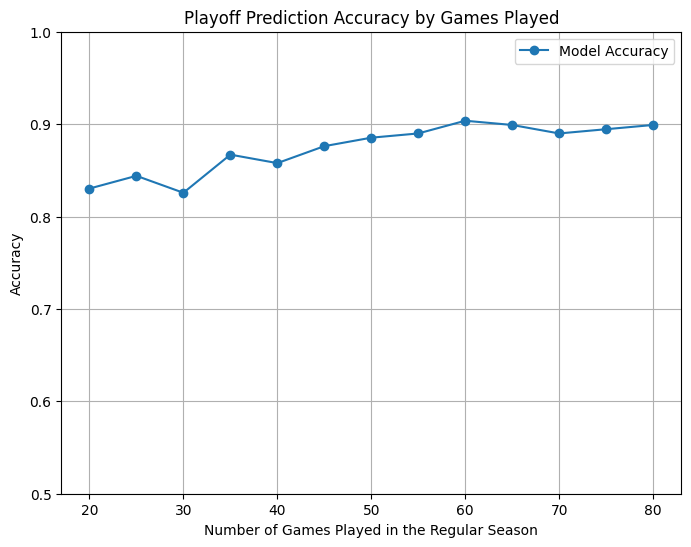

In [36]:
# graph
plt.figure(figsize=(8,6))
plt.plot(games_to_test, accuracy_results, marker='o', label='Model Accuracy')

plt.xlabel('Number of Games Played in the Regular Season')
plt.ylabel('Accuracy')
plt.title('Playoff Prediction Accuracy by Games Played')
plt.ylim(.5,1)
plt.legend()
plt.grid(True)

plt.show()

Based on our results, we can see that at the halfway mark of the NBA season, at 41 played games, the model can predict which 16 teams will make the playoffs with 86% accuracy. To push this further, we trained our model on different numbers of games in increments of 5 from 20 games to 80 played games. This displays what we assumed would be the case, as the number of games played increases, the ability to predict which teams will advance to the post season also increases. However, what is interesting is the graph shows that the accuracy increases until about the 60 played games mark, then stagnates for the remainded of the season. This means that for the most part the playoffs are pretty predictable at about the 75% mark of the season. This means the NBA could realistically decrease the amount of regular season games played with minimal impact on which teams will make the post season plus this will decrease injuries the players experience and improve viewer experience. It is not fun for the players, the team, or the fans when players, especially favorite players, are injured for long periods of time. The NBA should investigate potentially lowering the number of games played for the health and safety of NBA players.

---

#7. Insights and Conclusions.

We feel that after reading through our project, an uninformed reader would gain knowledge on our topic and have a good understanding of the problem we are attempting to investigate as well as the results and conclusions we came to. We believe a reader who already had knowledge on the NBA and injury problems within the NBA would especially gain insight from our project. Injury problems within the NBA are a known issue and a difficult one to solve. Although shortening the number of games in the regular season isn't an uncommon proposed solution, our project investigates how well this solution might work and what number of games the season should be shortened to. A fan of the NBA would definetely feel more knowledgable on the subject after reading through our investigation.